UNDERSTAND PROBLEM:
Loan lenders need to accurately predict whether a borrower will repay their loan to minimize financial loss.


Output: Binary Classification (0 = Charged Off, 1 = Fully Paid).
Goal: Minimize financial risk by identifying likely defaulters before approving a loan.
Target Metric: High Recall for Class 0 while keeping the precision at a decent percentage
Decision/Busines rule: If predicted risk is high → Reject. If predicted risk is low → Approve.
Algorithm: Logistic Regression
Datasets:
1. Train: https://www.kaggle.com/datasets/sananmammadov/credit-loan

Phase 1 — Data & Preprocessing:
1. Load dataset (same loan dataset from Assignment 1)
2. Handle missing values (imputation or removal)
3. Encode categorical variables (LabelEncoder / OneHotEncoder)
4. Apply StandardScaler to normalize numerical features
5. Apply SMOTE to balance the target class (after splitting)
6. Visualize: class distribution before/after SMOTE, correlation heatmap,
   feature distributions — all with Figure labels, cited in report body

Phase 2 — ML Implementation 
1. Logistic Regression (improved from Assignment 1)
2. Decision Tree Classifier
3. Random Forest Classifier
4. For each model:
   - Train using StratifiedKFold (5 folds)
   - Print: Confusion Matrix, Classification Report
     (actual precision, recall, F1, accuracy — not just definitions)
   - Record mean ± std across folds
5. Final comparison table of all 3 models

Phase 3 — Prototype / GUI:
Option A: Streamlit app (easier, web-based)
Option B: Tkinter GUI (desktop)

Features:
- Input fields: age, income, loan amount, loan intent, credit history, etc.
- "Predict" button
- Output: "Low Risk" / "High Risk" + probability score
- Use best-performing trained model (likely Random Forest)

Phase 4 — Report Writing:
Section 1: Introduction — background, problem, objectives, scope
Section 2: Literature Review — 8+ APA references (updated, no copy-paste from A1)
Section 3: Methodology — dataset, preprocessing justification, algorithms
Section 4: System Development — GUI screenshots, workflow diagram
Section 5: Results — actual metrics printed, confusion matrices, comparison table
Section 6: Conclusion — findings, challenges, future work, member contributions
References — APA format, include dataset URL and library links

In [69]:
# pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
#splitting data for model to study (train) and to test accuracy (test)
from sklearn.model_selection import train_test_split
#mathematical algorithm that will learn the patterns in data.
from sklearn.linear_model import LogisticRegression
# tell you how many loans the model predicted correctly.
from sklearn.metrics import (
    classification_report, 
    roc_auc_score, 
    accuracy_score,
    roc_curve, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE


LOAD AND EXPLORE THE DATA

In [71]:
train = pd.read_csv('cr_loan2.csv')

train.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [72]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [73]:
train.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

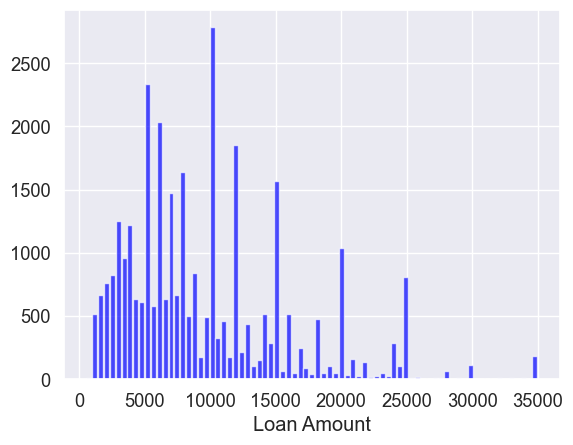

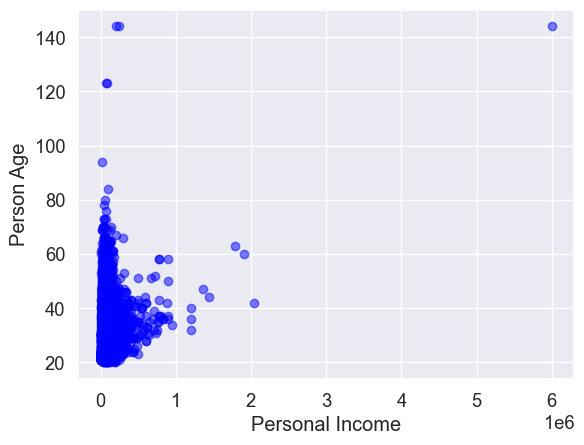

In [74]:
plt.hist(x=train['loan_amnt'], bins='auto', color='blue', alpha=0.7, rwidth=0.85)
plt.xlabel("Loan Amount")
plt.show()

plt.scatter(train['person_income'], train['person_age'], c='blue', alpha=0.5)
plt.xlabel('Personal Income')
plt.ylabel('Person Age')
plt.show()

Handle Missing Values

-loan_int_rate — filled with the column mean (imputation keeps all rows)
- person_emp_length — rows are dropped entirely since we can't reliably impute employment history

In [75]:
print(train.isnull().sum())
print("\nMissing %:")
print(train.isnull().mean() * 100)

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Missing %:
person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
person_emp_length             2.747000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_int_rate                 9.563856
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64


In [76]:
# ── Step 2: Drop columns with > 50% missing ─────────────────────────────
threshold = 0.5
df = train.loc[:, train.isnull().mean() < threshold]

In [77]:
# ── Step 3: Impute numerical columns ────────────────────────────────────
from sklearn.impute import SimpleImputer

num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Use MEDIAN (better for loan data — income/age are skewed)
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [78]:
# ── Step 4: Impute categorical columns ──────────────────────────────────
cat_cols = df.select_dtypes(include=['object']).columns

cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [79]:
# ── Step 5: Verify ───────────────────────────────────────────────────────
print("Remaining nulls:")
print(df.isnull().sum())
# Should all be 0

Remaining nulls:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


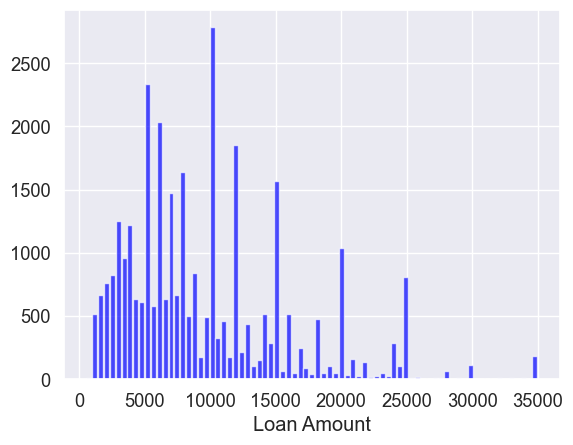

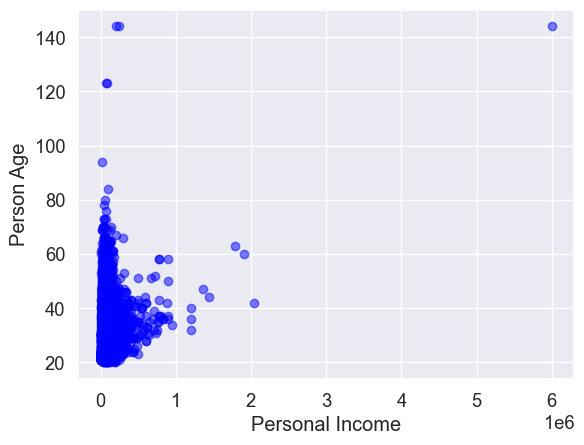

In [80]:
plt.hist(x=df['loan_amnt'], bins='auto', color='blue', alpha=0.7, rwidth=0.85)
plt.xlabel("Loan Amount")
plt.show()

plt.scatter(df['person_income'], df['person_age'], c='blue', alpha=0.5)
plt.xlabel('Personal Income')
plt.ylabel('Person Age')
plt.show()

In [81]:
df.shape

(32581, 12)

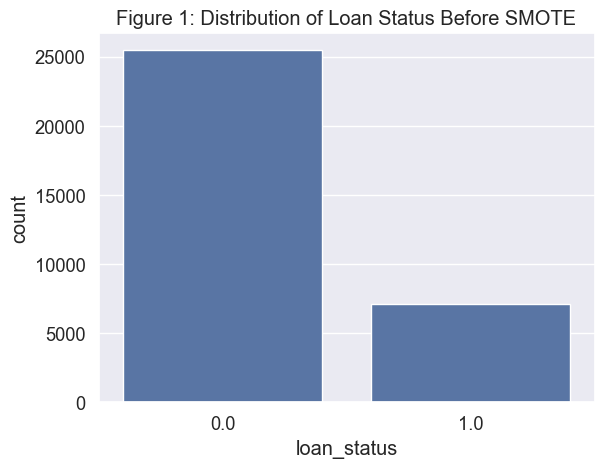

loan_status
0.0    0.781836
1.0    0.218164
Name: proportion, dtype: float64

In [82]:
sns.countplot(x='loan_status', data=df)
plt.title("Figure 1: Distribution of Loan Status Before SMOTE")
plt.show()

df['loan_status'].value_counts(normalize=True)

In [83]:
#Correlation with Target (Bar Plot)
temp_df = df.copy()

le = LabelEncoder()
for col in temp_df.select_dtypes(include='object'):
    temp_df[col] = le.fit_transform(temp_df[col])

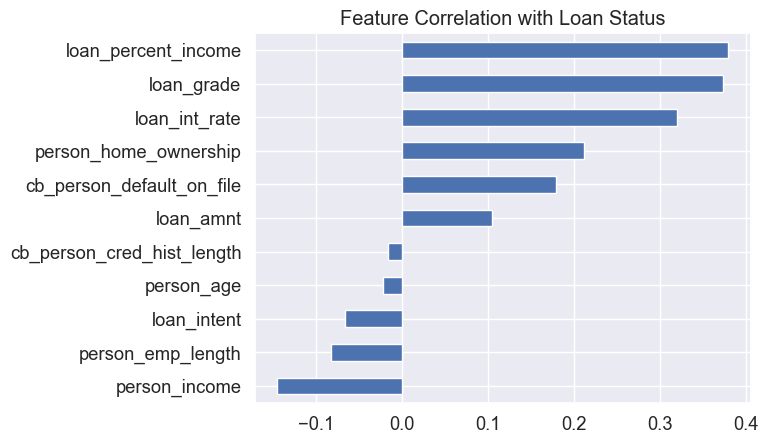

In [84]:
corr = temp_df.corr()

# correlation with target
target_corr = corr['loan_status'].drop('loan_status').sort_values()

target_corr.plot(kind='barh')
plt.title("Feature Correlation with Loan Status")
plt.show()

# positive correlation - increases likelihood of default (Class 0)
# negative correlation - increases likelihood of full repayment (Class 1)

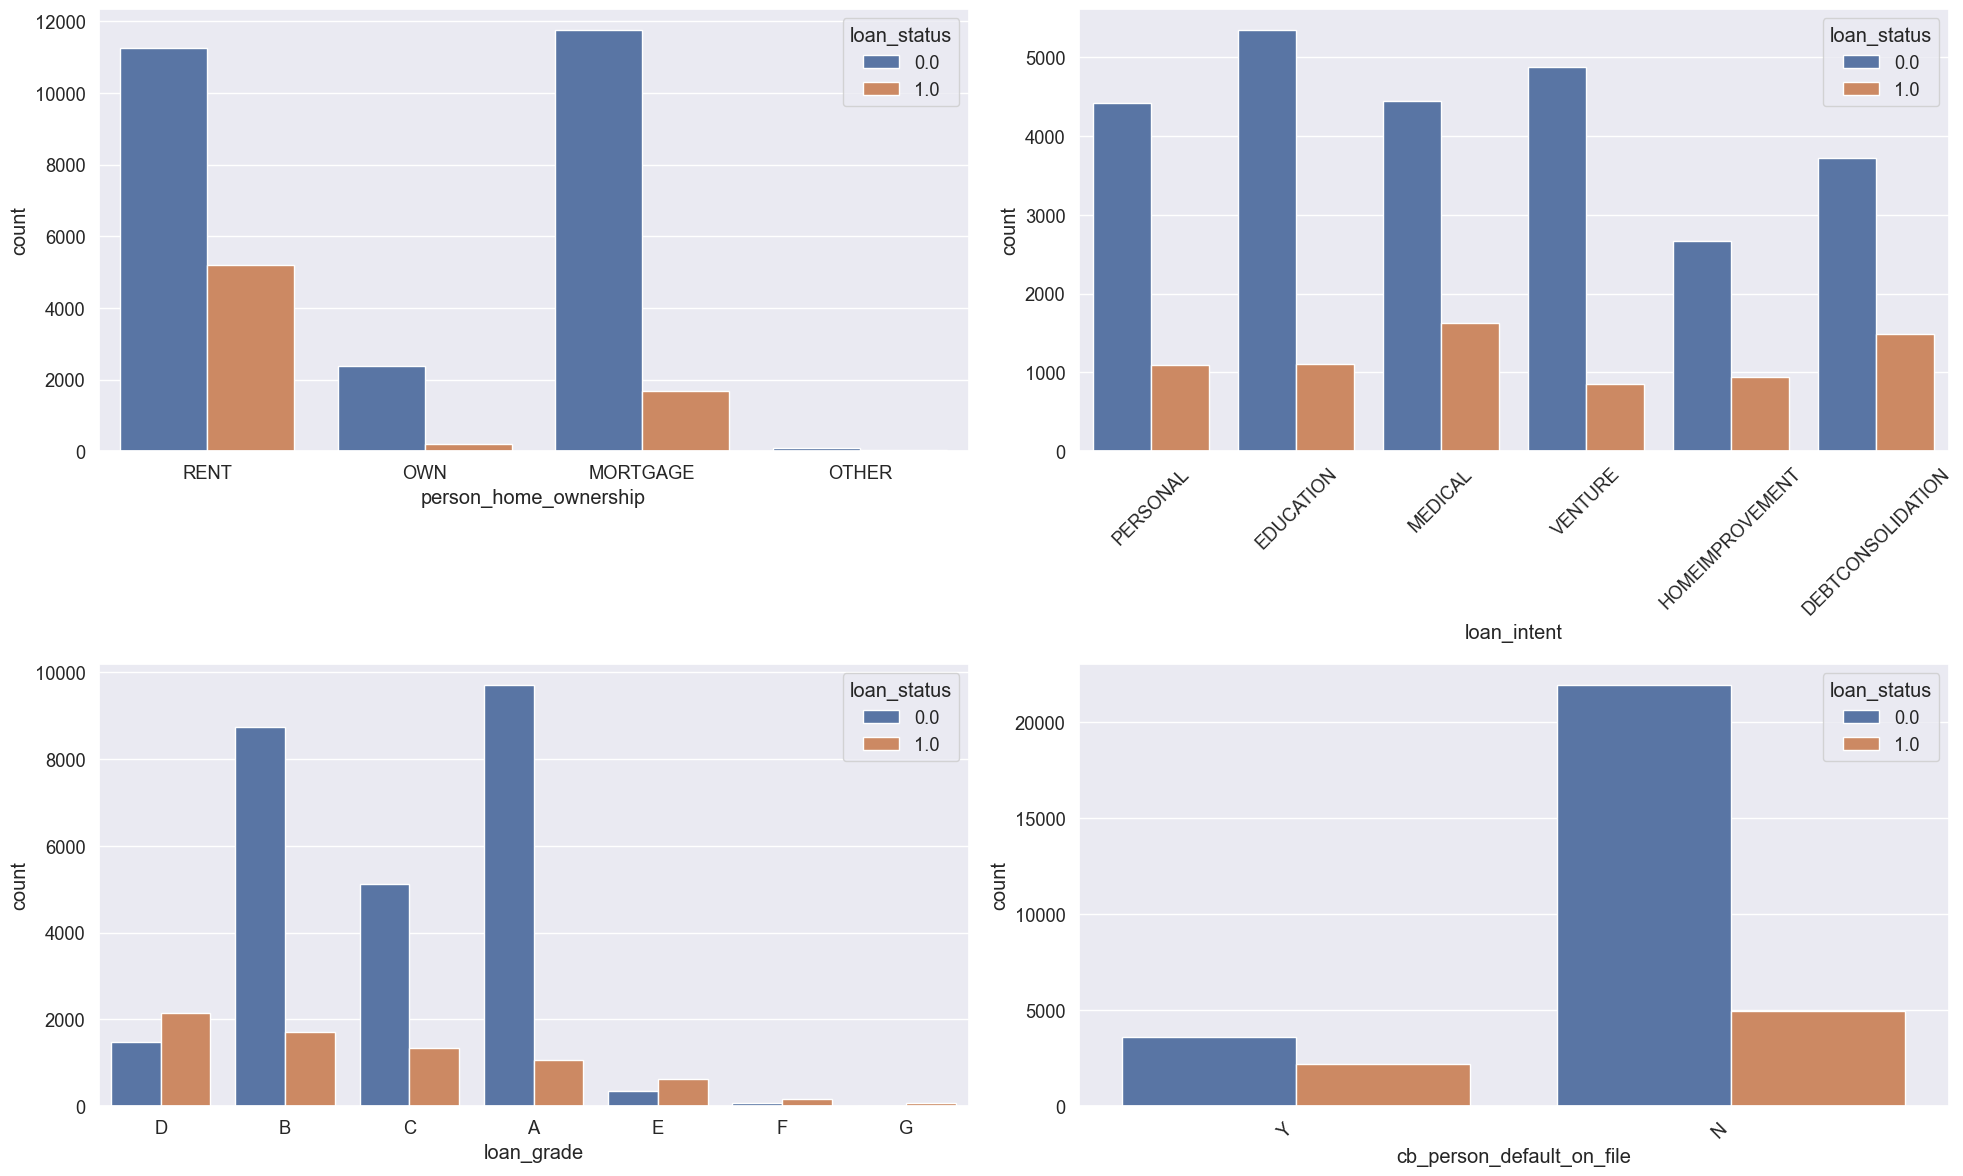

In [85]:
plt.figure(figsize=(20, 12)) # Slightly wider to give labels room
sns.set(font_scale=1.2) 

# Plot 1: person_home_ownership
plt.subplot(221) # Changed to 2x2 grid for better spacing
sns.countplot(x='person_home_ownership', hue='loan_status', data=df)

# Plot 2: loan_intent
plt.subplot(222)
sns.countplot(x='loan_intent', hue='loan_status', data=df)
plt.xticks(rotation=45) # Rotate labels so they don't overlap

# Plot 3: loan_grade
plt.subplot(223)
sns.countplot(x='loan_grade', hue='loan_status', data=df)

# Plot 4: cb_person_default_on_file
plt.subplot(224)
sns.countplot(x='cb_person_default_on_file', hue='loan_status', data=df)
plt.xticks(rotation=45, ha='right') # Rotate and align to the right

plt.tight_layout()
plt.show()

ENCODING CATEGORICAL VARIABLES

In [86]:
print(df['person_home_ownership'].unique())

<StringArray>
['RENT', 'OWN', 'MORTGAGE', 'OTHER']
Length: 4, dtype: str


In [87]:
pho_mapping = {
  'RENT': 0,
  'MORTGAGE': 1,
  'OWN': 2,
  'OTHER': 3
}

df['person_home_ownership'] = df['person_home_ownership'].map(pho_mapping)
df['person_home_ownership'].value_counts()

person_home_ownership
0    16446
1    13444
2     2584
3      107
Name: count, dtype: int64

In [88]:
print(df['loan_intent'].unique())

<StringArray>
[         'PERSONAL',         'EDUCATION',           'MEDICAL',
           'VENTURE',   'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
Length: 6, dtype: str


In [89]:
li_mapping = {
  'EDUCATION': 0, 
  'MEDICAL': 1, 
  'VENTURE': 2, 
  'PERSONAL': 3, 
  'DEBTCONSOLIDATION': 4, 
  'HOMEIMPROVEMENT': 5
}

df['loan_intent'] = df['loan_intent'].map(li_mapping)
df['loan_intent'].value_counts()

loan_intent
0    6453
1    6071
2    5719
3    5521
4    5212
5    3605
Name: count, dtype: int64

In [90]:
print(df['loan_grade'].unique())

<StringArray>
['D', 'B', 'C', 'A', 'E', 'F', 'G']
Length: 7, dtype: str


In [91]:
lg_mapping = {
  'A': 0, 
  'B': 1, 
  'C': 2, 
  'D': 3, 
  'E': 4, 
  'F': 5, 
  'G': 6
}

df['loan_grade'] = df['loan_grade'].map(lg_mapping)
df['loan_grade'].value_counts()

loan_grade
0    10777
1    10451
2     6458
3     3626
4      964
5      241
6       64
Name: count, dtype: int64

In [92]:
print(df['cb_person_default_on_file'].unique())

<StringArray>
['Y', 'N']
Length: 2, dtype: str


In [93]:
cb_mapping = {
  'N': 0, 
  'Y': 1
  }

df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map(cb_mapping)
df['cb_person_default_on_file'].value_counts()

cb_person_default_on_file
0    26836
1     5745
Name: count, dtype: int64

FINAL ENCODED DATASET

In [94]:
#FInal data frameeeeeeeeee
#All values have been change to numerical data
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22.0,59000.0,0,123.0,3,3,35000.0,16.02,1.0,0.59,1,3.0
1,21.0,9600.0,2,5.0,0,1,1000.0,11.14,0.0,0.10,0,2.0
2,25.0,9600.0,1,1.0,1,2,5500.0,12.87,1.0,0.57,0,3.0
3,23.0,65500.0,0,4.0,1,2,35000.0,15.23,1.0,0.53,0,2.0
4,24.0,54400.0,0,8.0,1,2,35000.0,14.27,1.0,0.55,1,4.0


TRAIN-TEST-SPLIT

In [95]:
df.shape

(32581, 12)

In [96]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')

In [121]:
#the clue
#independent variable
X = df.drop('loan_status', axis=1)


#the answer
#dependant variable and predicting
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

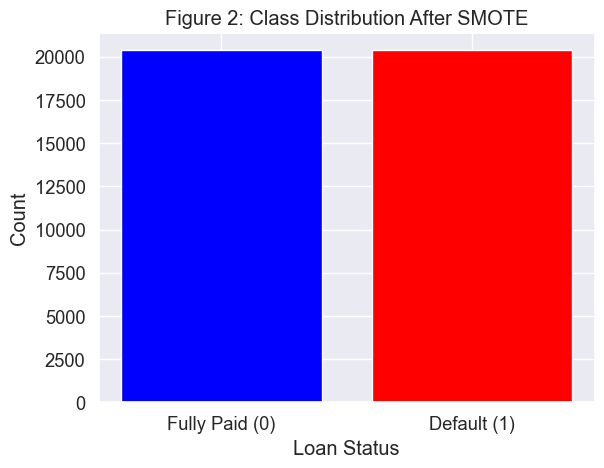

Counter({0.0: 20378, 1.0: 20378})


In [122]:
# Scale FIRST, then SMOTE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Visualize class distribution AFTER SMOTE
import collections
counter = collections.Counter(y_train_smote)
plt.bar(counter.keys(), counter.values(), color=['blue', 'red'])
plt.xticks([0, 1], ['Fully Paid (0)', 'Default (1)'])  
plt.title("Figure 2: Class Distribution After SMOTE")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()
print(counter)

In [99]:
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# model = LogisticRegression(class_weight='balanced', solver='lbfgs', max_iter=1000)
# model.fit(X_train_scaled, np.ravel(y_train))

# y_pred = model.predict(X_test_scaled)
# print('Logistic Regression Accuracy =', accuracy_score(y_test, y_pred))

In [100]:
# from sklearn.model_selection import StratifiedKFold
# from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import (classification_report, confusion_matrix, 
#                               ConfusionMatrixDisplay, f1_score, 
#                               precision_score, recall_score, accuracy_score)
# import numpy as np

# # Define models
# models = {
#     "Logistic Regression": LogisticRegression(class_weight='balanced', 
#                                                solver='lbfgs', max_iter=1000),
#     "Decision Tree":        DecisionTreeClassifier(class_weight='balanced', 
#                                                    random_state=42),
#     "Random Forest":        RandomForestClassifier(class_weight='balanced', 
#                                                    n_estimators=100, random_state=42)
# }

# # StratifiedKFold setup
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# # Store results for comparison table
# results = {}

# # Use X_train_resampled and y_train_resampled from SMOTE step above
# X_all = X_train_resampled
# y_all = y_train_resampled

# for model_name, model in models.items():
#     print(f"\n{'='*60}")
#     print(f"  {model_name}")
#     print(f"{'='*60}")
    
#     fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    
#     for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all), 1):
#         X_fold_train, X_fold_val = X_all[train_idx], X_all[val_idx]
#         y_fold_train, y_fold_val = y_all[train_idx], y_all[val_idx]
        
#         model.fit(X_fold_train, y_fold_train)
#         y_fold_pred = model.predict(X_fold_val)
        
#         fold_acc.append(accuracy_score(y_fold_val, y_fold_pred))
#         fold_prec.append(precision_score(y_fold_val, y_fold_pred, zero_division=0))
#         fold_rec.append(recall_score(y_fold_val, y_fold_pred))
#         fold_f1.append(f1_score(y_fold_val, y_fold_pred))
        
#         print(f"\n  --- Fold {fold} ---")
#         print(f"  Accuracy:  {fold_acc[-1]:.4f} | "
#               f"Precision: {fold_prec[-1]:.4f} | "
#               f"Recall: {fold_rec[-1]:.4f} | "
#               f"F1: {fold_f1[-1]:.4f}")
    
#     # Summary across folds
#     print(f"\n  >> Mean Accuracy:  {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
#     print(f"  >> Mean Precision: {np.mean(fold_prec):.4f} ± {np.std(fold_prec):.4f}")
#     print(f"  >> Mean Recall:    {np.mean(fold_rec):.4f} ± {np.std(fold_rec):.4f}")
#     print(f"  >> Mean F1-Score:  {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
    
#     # Final evaluation on held-out TEST SET
#     model.fit(X_all, y_all)
#     y_test_pred = model.predict(X_test_scaled)
    
#     print(f"\n  === Final Test Set Results: {model_name} ===")
#     print(classification_report(y_test, y_test_pred, 
#                                  target_names=['Default (0)', 'Fully Paid (1)']))
    
#     # Confusion Matrix with Figure label
#     cm = confusion_matrix(y_test, y_test_pred)
#     fig_num = list(models.keys()).index(model_name) + 3  # Figure 3, 4, 5
#     disp = ConfusionMatrixDisplay(cm, display_labels=['Default', 'Fully Paid'])
#     disp.plot()
#     plt.title(f"Figure {fig_num}: Confusion Matrix — {model_name}")
#     plt.show()
    
#     results[model_name] = {
#         'Accuracy':  f"{np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}",
#         'Precision': f"{np.mean(fold_prec):.4f} ± {np.std(fold_prec):.4f}",
#         'Recall':    f"{np.mean(fold_rec):.4f} ± {np.std(fold_rec):.4f}",
#         'F1-Score':  f"{np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}"
#     }

In [123]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Why SMOTE Only on Training Data?
The test set must represent the real world. In real life, loan defaults are rare — the imbalance is real and natural. If you apply SMOTE to test data, you're testing on fake data and your results become dishonestly good.
SMOTE is only a training trick to help the model learn defaults better. It should never touch your evaluation data.

Why Scale the Test Set But Not SMOTE It?
You still scale X_test because the model was trained on scaled numbers. If you feed it unscaled numbers during prediction, it won't understand the input — like writing an answer in a different unit than what was expected.


*********** Logistic Regression ************
Fold 1 — Accuracy: 0.7818 | Precision: 0.7865 | Recall: 0.7736 | F1: 0.7800
Fold 2 — Accuracy: 0.7854 | Precision: 0.7838 | Recall: 0.7882 | F1: 0.7860
Fold 3 — Accuracy: 0.7857 | Precision: 0.7891 | Recall: 0.7796 | F1: 0.7843
Fold 4 — Accuracy: 0.7840 | Precision: 0.7884 | Recall: 0.7763 | F1: 0.7823
Fold 5 — Accuracy: 0.7849 | Precision: 0.7886 | Recall: 0.7787 | F1: 0.7836

Mean Accuracy  : 0.7844
Mean Precision : 0.7873
Mean Recall    : 0.7793
Mean F1-Score  : 0.7832

Classification Report for Logistic Regression:
                precision    recall  f1-score   support

Fully Paid (0)       0.93      0.79      0.86      5095
   Default (1)       0.51      0.77      0.62      1422

      accuracy                           0.79      6517
     macro avg       0.72      0.78      0.74      6517
  weighted avg       0.84      0.79      0.80      6517



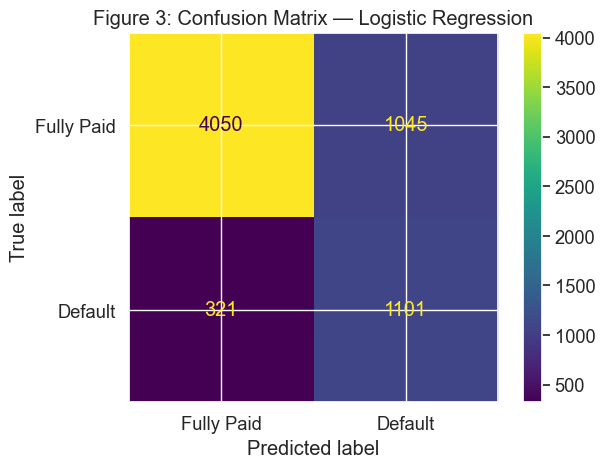

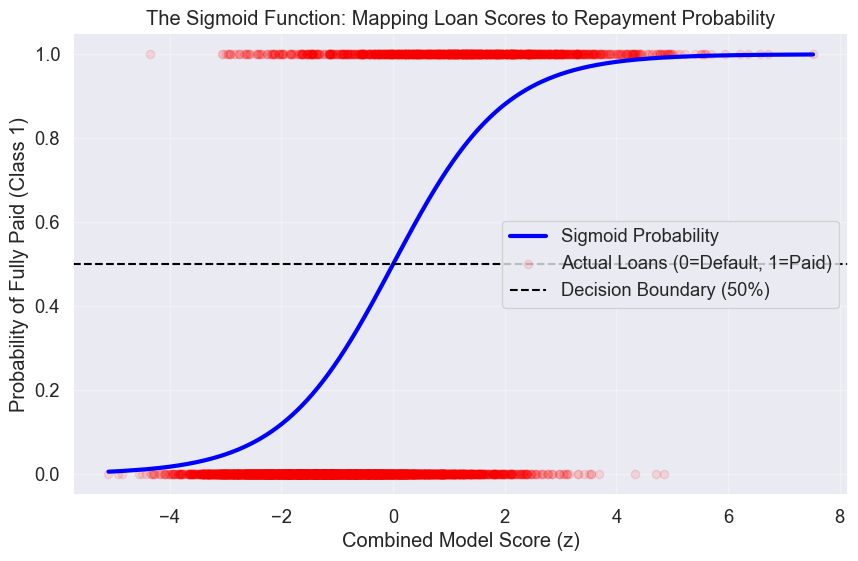

In [118]:
# FOR LOGISTIC REGRESSION

lr_model = LogisticRegression(class_weight='balanced', max_iter=1000)
# important for imbalance data bcs each folds keeps the same ratio of Class 0 and Class 1
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) 

lr_accuracy, lr_precision, lr_recall, lr_f1 = [], [], [], []

fold_num = 1
print("*********** Logistic Regression ************")
for lr_train_idx, lr_test_idx in skf.split(X_train_smote, y_train_smote):

    X_lr_fold_train  = X_train_smote[lr_train_idx]
    X_lr_fold_test = X_train_smote[lr_test_idx]
    y_lr_fold_train  = y_train_smote[lr_train_idx]
    y_lr_fold_test = y_train_smote[lr_test_idx]

    lr_model.fit(X_lr_fold_train, y_lr_fold_train)
    y_pred = lr_model.predict(X_lr_fold_test)

    lr_accuracy.append(accuracy_score(y_lr_fold_test, y_pred))
    lr_precision.append(precision_score(y_lr_fold_test, y_pred, zero_division=0))
    lr_recall.append(recall_score(y_lr_fold_test, y_pred))
    lr_f1.append(f1_score(y_lr_fold_test, y_pred))

    print(f"Fold {fold_num} — Accuracy: {lr_accuracy[-1]:.4f} | Precision: {lr_precision[-1]:.4f} | Recall: {lr_recall[-1]:.4f} | F1: {lr_f1[-1]:.4f}")
    fold_num += 1

print(f"\nMean Accuracy  : {np.mean(lr_accuracy):.4f}")
print(f"Mean Precision : {np.mean(lr_precision):.4f}")
print(f"Mean Recall    : {np.mean(lr_recall):.4f}")
print(f"Mean F1-Score  : {np.mean(lr_f1):.4f}")

# Final test
lr_model.fit(X_train_smote, y_train_smote)
y_lr_predict = lr_model.predict(X_test_scaled)
# the data that was never used at any point during training or validation
# This gives the most honest measure of real-world performance


print("\nClassification Report for Logistic Regression:")
print(classification_report(y_test, y_lr_predict, target_names=['Fully Paid (0)', 'Default (1)']))

cm = confusion_matrix(y_test, y_lr_predict)
ConfusionMatrixDisplay(cm, display_labels=['Fully Paid', 'Default']).plot()
plt.title("Figure 3: Confusion Matrix — Logistic Regression")
plt.show()


# 1. Compute the decision score z for every loan in the test set
z = lr_model.decision_function(X_test_scaled)

# 2. Get the predicted probability of Class 1 (Fully Paid)
probabilities = lr_model.predict_proba(X_test_scaled)[:, 1]

# 3. Sort by z so the sigmoid line draws smoothly left to right
sort_idx = np.argsort(z)
z_sorted = z[sort_idx]
prob_sorted = probabilities[sort_idx]

# 4. Plot
plt.figure(figsize=(10, 6))
plt.plot(z_sorted, prob_sorted, color='blue', linewidth=3, label='Sigmoid Probability')
plt.scatter(z, y_test, color='red', alpha=0.1, label='Actual Loans (0=Default, 1=Paid)')
plt.axhline(0.5, color='black', linestyle='--', label='Decision Boundary (50%)')
plt.title('The Sigmoid Function: Mapping Loan Scores to Repayment Probability')
plt.xlabel('Combined Model Score (z)')
plt.ylabel('Probability of Fully Paid (Class 1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

******** Decision Tree ********** 
Fold 1 — Acc: 0.9043 | Prec: 0.8988 | Rec: 0.9112 | F1: 0.9050
Fold 2 — Acc: 0.8988 | Prec: 0.8878 | Rec: 0.9129 | F1: 0.9002
Fold 3 — Acc: 0.8978 | Prec: 0.8952 | Rec: 0.9011 | F1: 0.8981
Fold 4 — Acc: 0.8972 | Prec: 0.8933 | Rec: 0.9021 | F1: 0.8977
Fold 5 — Acc: 0.9028 | Prec: 0.8966 | Rec: 0.9107 | F1: 0.9036

Mean Accuracy  : 0.9002
Mean Precision : 0.8944
Mean Recall    : 0.9076
Mean F1-Score  : 0.9009

Classification Report — Decision Tree:
                precision    recall  f1-score   support

Fully Paid (0)       0.94      0.91      0.92      5095
   Default (1)       0.70      0.77      0.74      1422

      accuracy                           0.88      6517
     macro avg       0.82      0.84      0.83      6517
  weighted avg       0.88      0.88      0.88      6517



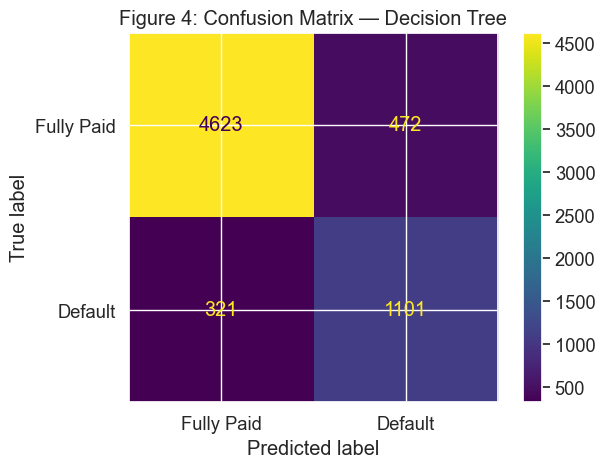

In [ ]:
# FOR DECISION TREE

dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_accuracy, dt_precision, dt_recall, dt_f1 = [], [], [], []

fold_num = 1
print("******** Decision Tree ********** ")
for dt_train_idx, dt_test_idx in skf.split(X_train_smote, y_train_smote):

    X_dt_fold_train  = X_train_smote[dt_train_idx]
    X_dt_fold_test = X_train_smote[dt_test_idx]
    y_dt_fold_train  = y_train_smote[dt_train_idx]
    y_dt_fold_test = y_train_smote[dt_test_idx]

    dt_model.fit(X_dt_fold_train, y_dt_fold_train)
    y_pred = dt_model.predict(X_dt_fold_test)

    dt_accuracy.append(accuracy_score(y_dt_fold_test, y_pred))
    dt_precision.append(precision_score(y_dt_fold_test, y_pred, zero_division=0))
    dt_recall.append(recall_score(y_dt_fold_test, y_pred))
    dt_f1.append(f1_score(y_dt_fold_test, y_pred))

    print(f"Fold {fold_num} — Acc: {dt_accuracy[-1]:.4f} | Prec: {dt_precision[-1]:.4f} | Rec: {dt_recall[-1]:.4f} | F1: {dt_f1[-1]:.4f}")
    fold_num += 1

print(f"\nMean Accuracy  : {np.mean(dt_accuracy):.4f}")
print(f"Mean Precision : {np.mean(dt_precision):.4f}")
print(f"Mean Recall    : {np.mean(dt_recall):.4f}")
print(f"Mean F1-Score  : {np.mean(dt_f1):.4f}")

# Final test
dt_model.fit(X_train_smote, y_train_smote)
y_dt_predict = dt_model.predict(X_test_scaled)

print("\nClassification Report — Decision Tree:")
print(classification_report(y_test, y_dt_predict, target_names=['Fully Paid (0)', 'Default (1)']))

cm = confusion_matrix(y_test, y_dt_predict)
ConfusionMatrixDisplay(cm, display_labels=['Fully Paid', 'Default']).plot()
plt.title("Figure 4: Confusion Matrix for Decision Tree")
plt.show()

******* Random Forest ****
Fold 1 — Acc: 0.9444 | Prec: 0.9832 | Rec: 0.9043 | F1: 0.9421
Fold 2 — Acc: 0.9438 | Prec: 0.9783 | Rec: 0.9077 | F1: 0.9417
Fold 3 — Acc: 0.9466 | Prec: 0.9787 | Rec: 0.9131 | F1: 0.9448
Fold 4 — Acc: 0.9465 | Prec: 0.9800 | Rec: 0.9117 | F1: 0.9446
Fold 5 — Acc: 0.9488 | Prec: 0.9783 | Rec: 0.9181 | F1: 0.9472

Mean Accuracy  : 0.9460
Mean Precision : 0.9797
Mean Recall    : 0.9110
Mean F1-Score  : 0.9441

Classification Report — Random Forest:
                precision    recall  f1-score   support

Fully Paid (0)       0.93      0.99      0.96      5095
   Default (1)       0.94      0.74      0.82      1422

      accuracy                           0.93      6517
     macro avg       0.93      0.86      0.89      6517
  weighted avg       0.93      0.93      0.93      6517



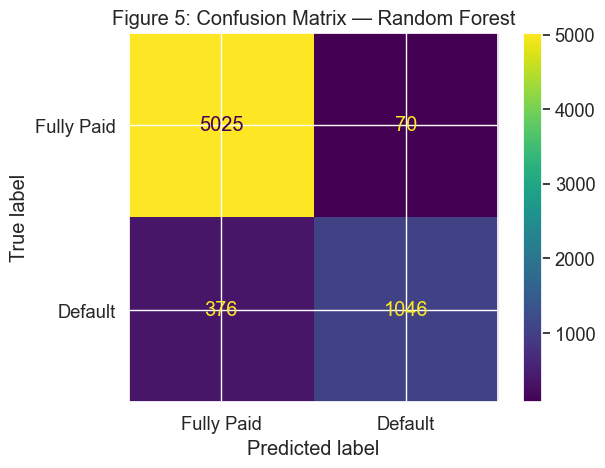

In [124]:
# RANDOM FOREST

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_accuracy, rf_precision, rf_recall, rf_f1 = [], [], [], []

fold_num = 1
print("******* Random Forest ****")
for rf_train_idx, rf_test_idx in skf.split(X_train_smote, y_train_smote):

    X_rf_fold_train  = X_train_smote[rf_train_idx]
    X_rf_fold_test = X_train_smote[rf_test_idx]
    y_rf_fold_train = y_train_smote[rf_train_idx]
    y_rf_fold_test = y_train_smote[rf_test_idx]

    rf_model.fit(X_rf_fold_train, y_rf_fold_train)
    y_pred = rf_model.predict(X_rf_fold_test)

    rf_accuracy.append(accuracy_score(y_rf_fold_test, y_pred))
    rf_precision.append(precision_score(y_rf_fold_test, y_pred, zero_division=0))
    rf_recall.append(recall_score(y_rf_fold_test, y_pred))
    rf_f1.append(f1_score(y_rf_fold_test, y_pred))

    print(f"Fold {fold_num} — Acc: {rf_accuracy[-1]:.4f} | Prec: {rf_precision[-1]:.4f} | Rec: {rf_recall[-1]:.4f} | F1: {rf_f1[-1]:.4f}")
    fold_num += 1

print(f"\nMean Accuracy  : {np.mean(rf_accuracy):.4f}")
print(f"Mean Precision : {np.mean(rf_precision):.4f}")
print(f"Mean Recall    : {np.mean(rf_recall):.4f}")
print(f"Mean F1-Score  : {np.mean(rf_f1):.4f}")

# Final test
rf_model.fit(X_train_smote, y_train_smote)
y_rf_pred = rf_model.predict(X_test_scaled)

print("\nClassification Report — Random Forest:")
print(classification_report(y_test, y_rf_pred, target_names=['Fully Paid (0)', 'Default (1)']))

cm = confusion_matrix(y_test, y_rf_pred)
ConfusionMatrixDisplay(cm, display_labels=['Fully Paid', 'Default']).plot()
plt.title("Figure 5: Confusion Matrix — Random Forest")
plt.show()

========== Model Comparison Table (5-Fold CV) ==========
Model                  Accuracy     Precision    Recall       F1-Score
-----------------------------------------------------------------
Logistic Regression    0.7844       0.7873       0.7793       0.7832
Decision Tree          0.9002       0.8944       0.9076       0.9009
Random Forest          0.9460       0.9797       0.9110       0.9441


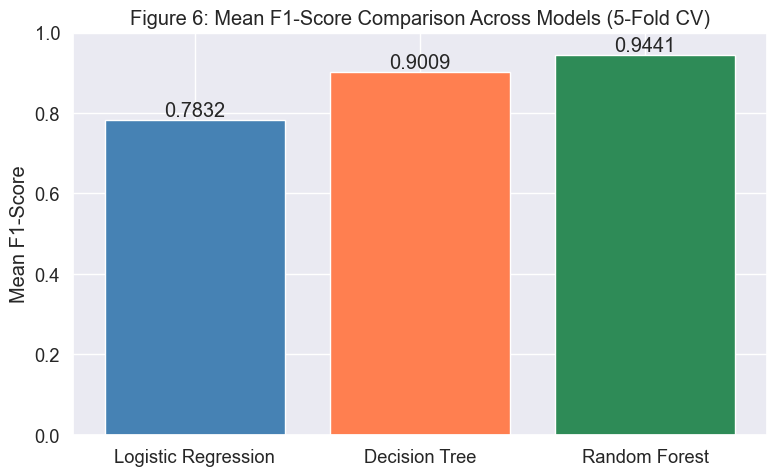

In [126]:
print("========== Model Comparison Table (5-Fold CV) ==========")
print(f"{'Model':<22} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score'}")
print("-" * 65)
print(f"{'Logistic Regression':<22} {np.mean(lr_accuracy):.4f}       {np.mean(lr_precision):.4f}       {np.mean(lr_recall):.4f}       {np.mean(lr_f1):.4f}")
print(f"{'Decision Tree':<22} {np.mean(dt_accuracy):.4f}       {np.mean(dt_precision):.4f}       {np.mean(dt_recall):.4f}       {np.mean(dt_f1):.4f}")
print(f"{'Random Forest':<22} {np.mean(rf_accuracy):.4f}       {np.mean(rf_precision):.4f}       {np.mean(rf_recall):.4f}       {np.mean(rf_f1):.4f}")

model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']

mean_f1_scores = [
    np.mean(lr_f1),
    np.mean(dt_f1),
    np.mean(rf_f1)
]

plt.figure(figsize=(8, 5))
plt.bar(model_names, mean_f1_scores, color=['steelblue', 'coral', 'seagreen'])
plt.title("Figure 6: Mean F1-Score Comparison Across Models (5-Fold CV)")
plt.ylabel("Mean F1-Score")
plt.ylim(0, 1)

# Show value on top of each bar
for i, v in enumerate(mean_f1_scores):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')

plt.tight_layout()
plt.show()

In [127]:
import pickle

# Save the trained Random Forest model
pickle.dump(rf_model, open('rf_model.pkl', 'wb'))

# Save the scaler too — IMPORTANT!
# Streamlit needs to scale user input the same way we scaled training data
pickle.dump(scaler, open('scaler.pkl', 'wb'))

print("rf_model.pkl saved!")
print("scaler.pkl saved!")

rf_model.pkl saved!
scaler.pkl saved!


In [ ]:
# import streamlit as st
# import pickle
# import numpy as np

# # Load saved model and scaler
# rf_model = pickle.load(open('rf_model.pkl', 'rb'))
# scaler   = pickle.load(open('scaler.pkl', 'rb'))

# st.title("Loan Default Risk Predictor")
# st.write("Fill in the applicant details below to predict loan risk.")

# # ── Input Fields ────────────────────────────────────────────────
# person_age = st.number_input("Age", min_value=18, max_value=100, value=30)

# person_income = st.number_input("Annual Income (RM)", min_value=0, value=50000)

# person_home_ownership = st.selectbox(
#     "Home Ownership",
#     options=[0, 1, 2, 3],
#     format_func=lambda x: {0: "Rent", 1: "Mortgage", 2: "Own", 3: "Other"}[x]
# )

# person_emp_length = st.number_input("Employment Length (years)", min_value=0, max_value=50, value=5)

# loan_intent = st.selectbox(
#     "Loan Intent",
#     options=[0, 1, 2, 3, 4, 5],
#     format_func=lambda x: {
#         0: "Education", 1: "Medical", 2: "Venture",
#         3: "Personal", 4: "Debt Consolidation", 5: "Home Improvement"
#     }[x]
# )

# loan_grade = st.selectbox(
#     "Loan Grade",
#     options=[0, 1, 2, 3, 4, 5, 6],
#     format_func=lambda x: {0: "A", 1: "B", 2: "C", 3: "D", 4: "E", 5: "F", 6: "G"}[x]
# )

# loan_amnt = st.number_input("Loan Amount (RM)", min_value=0, value=10000)

# loan_int_rate = st.number_input("Interest Rate (%)", min_value=0.0, max_value=30.0, value=10.0)

# loan_percent_income = st.number_input("Loan as % of Income (0.0 - 1.0)", min_value=0.0, max_value=1.0, value=0.2)

# cb_person_default_on_file = st.selectbox(
#     "Previous Default on Record?",
#     options=[0, 1],
#     format_func=lambda x: {0: "No", 1: "Yes"}[x]
# )

# cb_person_cred_hist_length = st.number_input("Credit History Length (years)", min_value=0, max_value=30, value=5)

# # ── Predict Button ───────────────────────────────────────────────
# if st.button("Predict Risk"):

#     # Arrange input in same column order as training data
#     input_data = np.array([[
#         person_age,
#         person_income,
#         person_home_ownership,
#         person_emp_length,
#         loan_intent,
#         loan_grade,
#         loan_amnt,
#         loan_int_rate,
#         loan_percent_income,
#         cb_person_default_on_file,
#         cb_person_cred_hist_length
#     ]])

#     # Scale using the same scaler from training
#     input_scaled = scaler.transform(input_data)

#     # Predict
#     prediction   = rf_model.predict(input_scaled)[0]
#     probability  = rf_model.predict_proba(input_scaled)[0]

#     default_prob  = probability[1] * 100  # probability of Default (1)
#     paid_prob     = probability[0] * 100  # probability of Fully Paid (0)

#     st.subheader("Prediction Result")

#     if prediction == 1:
#         st.error(f"⚠️ HIGH RISK — Likely to Default")
#     else:
#         st.success(f"✅ LOW RISK — Likely to Fully Pay")

#     st.write(f"Probability of Default:    **{default_prob:.1f}%**")
#     st.write(f"Probability of Fully Paid: **{paid_prob:.1f}%**")

ModuleNotFoundError: No module named 'streamlit'

In [ ]:
# pip install streamlit
# streamlit run app.py